In [ ]:
"""
Generates, for each ocean, a file containing:
  - platform_number
  - cycle_number
  - real_label       (Anomaly / Normal)
  - predicted_label  (Anomaly / Normal)
  - prediction_type  (TP / TN / FP / FN)

Uses the artifacts already saved by the training script
(lgbm_train.py):
    <model_dir>/test_results.parquet

which contains df_test_meta + y_pred + y_pred_proba.

Output:
    /.../MinMax/lightgbm_predictions/
        <ocean>_predictions.parquet
        <ocean>_predictions.csv
        all_oceans_predictions.parquet  (optional, all oceans combined)
"""

import os
import pandas as pd

# CONFIG

OCEANS = {
    "Atlantic": "/work/drgarcia/Models_and_results/LightGBM/2018_2022/atlantic_f1macro_time_asc_nounder",
    "Indian":   "/work/drgarcia/Models_and_results/LightGBM/2018_2022/indian_f1macro_time_asc_nounder",
    "Pacific":  "/work/drgarcia/Models_and_results/LightGBM/2018_2022/pacific_f1macro_time_asc_nounder",
}

OUTPUT_DIR = "/home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax/lightgbm_predictions"

# Columns in test_results.parquet.
COL_PLATFORM = "PLATFORM_NUMBER"
COL_CYCLE    = "CYCLE_NUMBER"
COL_TRUE     = "is_bad"        # 0 = Normal, 1 = Anomaly (real label)
COL_PRED     = "y_pred"        # 0/1 (model prediction)


# FUNCTIONS

def classify_prediction(row):
    """Returns TP/TN/FP/FN by comparing the true and predicted labels."""
    y_true = row[COL_TRUE]
    y_pred = row[COL_PRED]

    if y_true == 1 and y_pred == 1:
        return "TP"
    elif y_true == 0 and y_pred == 0:
        return "TN"
    elif y_true == 0 and y_pred == 1:
        return "FP"
    elif y_true == 1 and y_pred == 0:
        return "FN"
    else:
        return "UNKNOWN"


def process_ocean(ocean_name, model_dir):
    results_path = os.path.join(model_dir, "test_results.parquet")

    if not os.path.exists(results_path):
        print(f"  [!] No se encontro: {results_path}  -> se salta {ocean_name}")
        return None

    df = pd.read_parquet(results_path)

    missing = [c for c in [COL_PLATFORM, COL_CYCLE, COL_TRUE, COL_PRED] if c not in df.columns]
    if missing:
        print(f"  [!] {ocean_name}: missing columns {missing} in test_results.parquet")
        print(f"       columns dispo: {list(df.columns)}")
        return None

    out = pd.DataFrame({
        "ocean":           ocean_name,
        "platform_number": df[COL_PLATFORM],
        "cycle_number":    df[COL_CYCLE],
        "real_label":      df[COL_TRUE].map({0: "Normal", 1: "Anomaly"}),
        "predicted_label": df[COL_PRED].map({0: "Normal", 1: "Anomaly"}),
    })

    out["prediction_type"] = df.apply(classify_prediction, axis=1).values

    # opcional: guarda tambien la probabilidad si existe
    if "y_pred_proba" in df.columns:
        out["pred_probability"] = df["y_pred_proba"].values

    return out


def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    all_dfs = []

    for ocean_name, model_dir in OCEANS.items():
        print(f"\nProcesing {ocean_name} ...")
        df_out = process_ocean(ocean_name, model_dir)

        if df_out is None:
            continue

        # resumen rapido en consola
        print(df_out["prediction_type"].value_counts())

        # guarda por oceano
        parquet_path = os.path.join(OUTPUT_DIR, f"{ocean_name.lower()}_predictions.parquet")
        csv_path     = os.path.join(OUTPUT_DIR, f"{ocean_name.lower()}_predictions.csv")
        df_out.to_parquet(parquet_path, index=False)
        df_out.to_csv(csv_path, index=False)
        print(f"  -> save: {parquet_path}")
        print(f"  -> save: {csv_path}")

        all_dfs.append(df_out)

    if all_dfs:
        df_all = pd.concat(all_dfs, ignore_index=True)
        all_parquet = os.path.join(OUTPUT_DIR, "all_oceans_predictions.parquet")
        all_csv     = os.path.join(OUTPUT_DIR, "all_oceans_predictions.csv")
        df_all.to_parquet(all_parquet, index=False)
        df_all.to_csv(all_csv, index=False)
        print(f"\nCombined file saved in:\n  {all_parquet}\n  {all_csv}")
    else:
        print("\n No files were generated (check the paths / column names)")


if __name__ == "__main__":
    main()


Procesando Atlantic ...


prediction_type
TN    27278
TP     9562
FN     4622
FP     2188
Name: count, dtype: int64
  -> guardado: /home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax2/lightgbm_predictions/atlantic_predictions.parquet
  -> guardado: /home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax2/lightgbm_predictions/atlantic_predictions.csv

Procesando Indian ...


prediction_type
TN    9799
TP    9365
FN    2363
FP    1253
Name: count, dtype: int64
  -> guardado: /home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax2/lightgbm_predictions/indian_predictions.parquet
  -> guardado: /home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax2/lightgbm_predictions/indian_predictions.csv

Procesando Pacific ...


prediction_type
TP    32176
TN    26501
FN     7857
FP     3064
Name: count, dtype: int64
  -> guardado: /home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax2/lightgbm_predictions/pacific_predictions.parquet
  -> guardado: /home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax2/lightgbm_predictions/pacific_predictions.csv



Archivo combinado guardado en:
  /home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax2/lightgbm_predictions/all_oceans_predictions.parquet
  /home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax2/lightgbm_predictions/all_oceans_predictions.csv


In [ ]:
# Load CSV chooses 5 examples
import os
import sys
import requests
import numpy as np
import pandas as pd
 
# Base directory containing Tools_MinMax_ISEA.py, AUX_files/, and REFERENCE_FILES/
BASE_DIR = "/home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax"
sys.path.insert(0, BASE_DIR)  
 
CSV_PATH = os.path.join(BASE_DIR, "lightgbm_predictions", "all_oceans_predictions.csv")
DOWNLOAD_DIR = os.path.join(BASE_DIR, "AUX_files")
N_EXAMPLES = 5
RANDOM_SEED = 42
 
os.makedirs(DOWNLOAD_DIR, exist_ok=True)
 
df = pd.read_csv(CSV_PATH)
 
required_cols = {"platform_number", "cycle_number", "real_label",
                  "predicted_label", "prediction_type"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas en el CSV: {missing}. "
                      f"Columnas disponibles: {list(df.columns)}")
 
 
def sample_category(df, category, n=N_EXAMPLES, seed=RANDOM_SEED):
    subset = df[df["prediction_type"] == category]
    if len(subset) == 0:
        print(f"  [!] No hay ejemplos para la categoria {category}")
        return subset
    return subset.sample(n=min(n, len(subset)), random_state=seed)
 
 
print("Seleccionando ejemplos por categoria...")
examples_TP = sample_category(df, "TP")   # anomalias reales, modelo acerto
examples_TN = sample_category(df, "TN")   # normales reales, modelo acerto
examples_FP = sample_category(df, "FP")   # normales reales, modelo fallo (predijo anomalia)
examples_FN = sample_category(df, "FN")   # anomalias reales, modelo fallo (predijo normal)
 
selected = pd.concat([examples_TP, examples_TN, examples_FP, examples_FN],
                      ignore_index=True)
 
print(f"\nTotal de perfiles seleccionados: {len(selected)}")
print(selected[["ocean", "platform_number", "cycle_number",
                 "real_label", "predicted_label", "prediction_type"]])
 
# Load only some platforms
 
# try different names
DAC_LIST = ["aoml", "bodc", "coriolis", "csio", "csiro", "incois",
            "jma", "kma", "kordi", "meds", "nmdis"]
 
BASE_URL = "https://data-argo.ifremer.fr/dac"
 
 
def find_and_download_profile(platform_number, download_dir=DOWNLOAD_DIR):
    """Dowload <platform_number>_prof.nc trying every DAC, unless the file exists already."""
    local_path = os.path.join(download_dir, f"{platform_number}_prof.nc")
    if os.path.exists(local_path):
        print(f"  - {platform_number}: Already exists locally, skipping download.")
        return local_path
 
    for dac in DAC_LIST:
        url = f"{BASE_URL}/{dac}/{platform_number}/{platform_number}_prof.nc"
        try:
            r = requests.get(url, timeout=30, stream=True)
            if r.status_code == 200:
                with open(local_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
                print(f"  - {platform_number}: dowloaded (dac={dac})")
                return local_path
        except requests.exceptions.RequestException:
            continue
 
    print(f"  [!] {platform_number}: Could not be found in any DAC.")
    return None
 
 
unique_platforms = selected["platform_number"].unique()
print(f"\nDowloading {len(unique_platforms)} unique platforms "
      f"(Those required for the {len(selected)} profiles)...")
 
downloaded_files = {}
for p in unique_platforms:
    downloaded_files[int(p)] = find_and_download_profile(int(p))

Seleccionando ejemplos por categoria...

Total de perfiles seleccionados: 20
       ocean  platform_number  cycle_number real_label predicted_label  \
0     Indian          5906140          84.0    Anomaly         Anomaly   
1    Pacific          5905796         117.0    Anomaly         Anomaly   
2    Pacific          4903026          51.0    Anomaly         Anomaly   
3    Pacific          5906529          20.0    Anomaly         Anomaly   
4   Atlantic          4902111         237.0    Anomaly         Anomaly   
5   Atlantic          6900892         116.0     Normal          Normal   
6    Pacific          5906354          37.0     Normal          Normal   
7    Pacific          4903322          86.0     Normal          Normal   
8    Pacific          5905025         249.0     Normal          Normal   
9   Atlantic          1901828         299.0     Normal          Normal   
10   Pacific          5902411         280.0     Normal         Anomaly   
11    Indian          5905404      

Chargement des fichiers de référence Min/Max...



---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5906140 | Cycle = 84
Résultat LightGBM : Vrai Positif (Anomalie correctement détectée)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


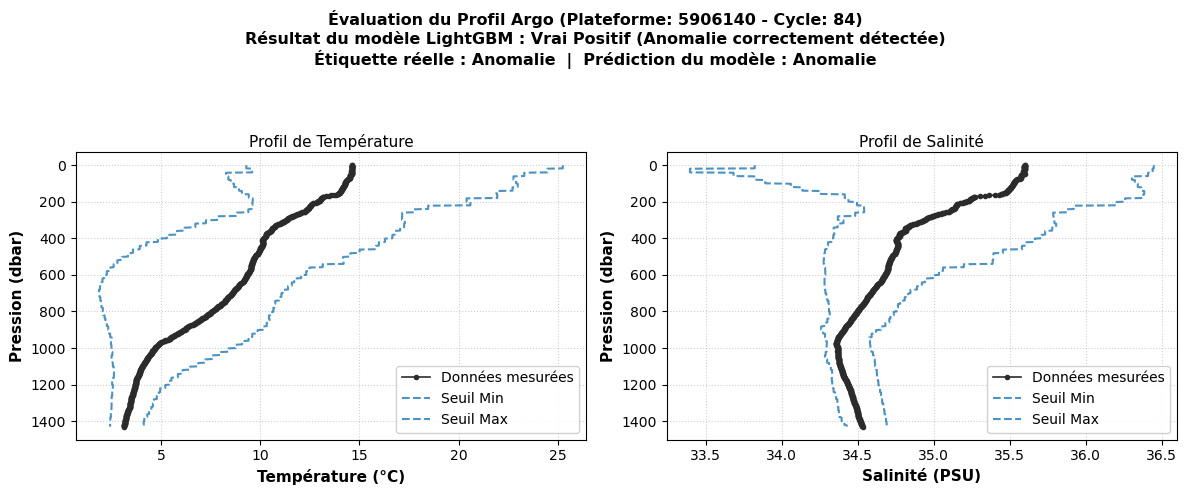


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5905796 | Cycle = 117
Résultat LightGBM : Vrai Positif (Anomalie correctement détectée)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 721 points | Température : 0 points
---------------------------------------------------------------------------


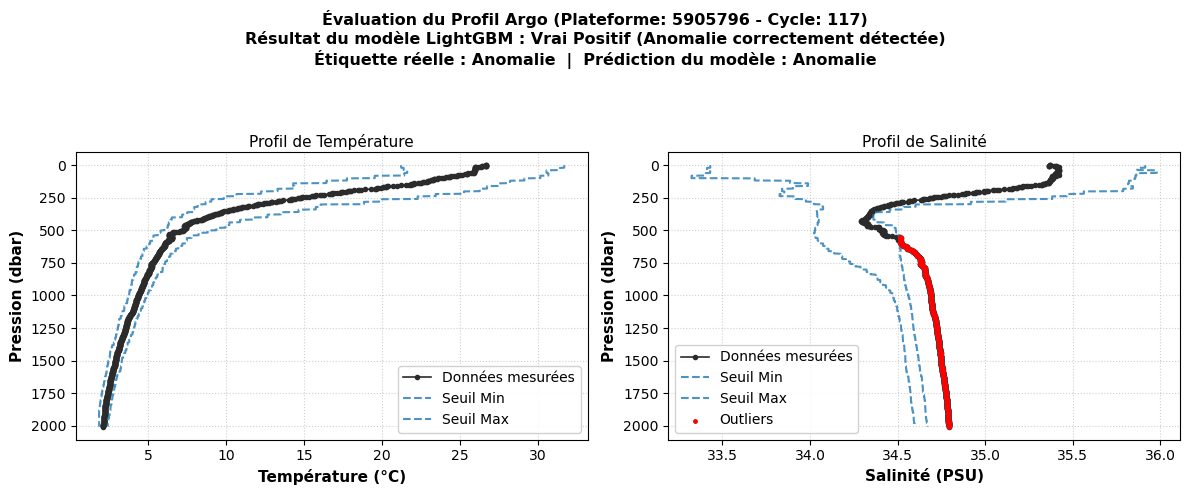


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 4903026 | Cycle = 51
Résultat LightGBM : Vrai Positif (Anomalie correctement détectée)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 34 points | Température : 0 points
---------------------------------------------------------------------------


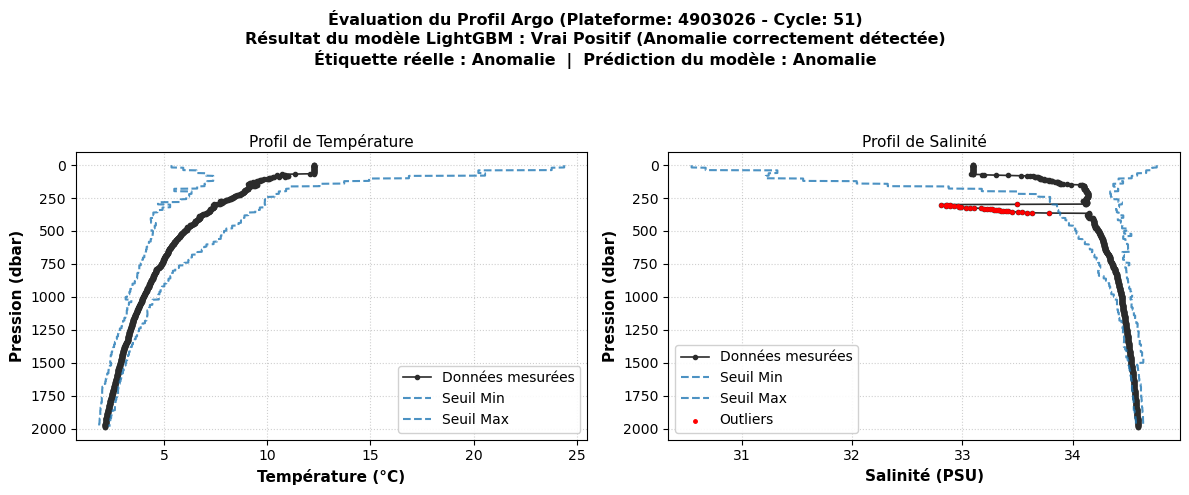


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5906529 | Cycle = 20
Résultat LightGBM : Vrai Positif (Anomalie correctement détectée)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


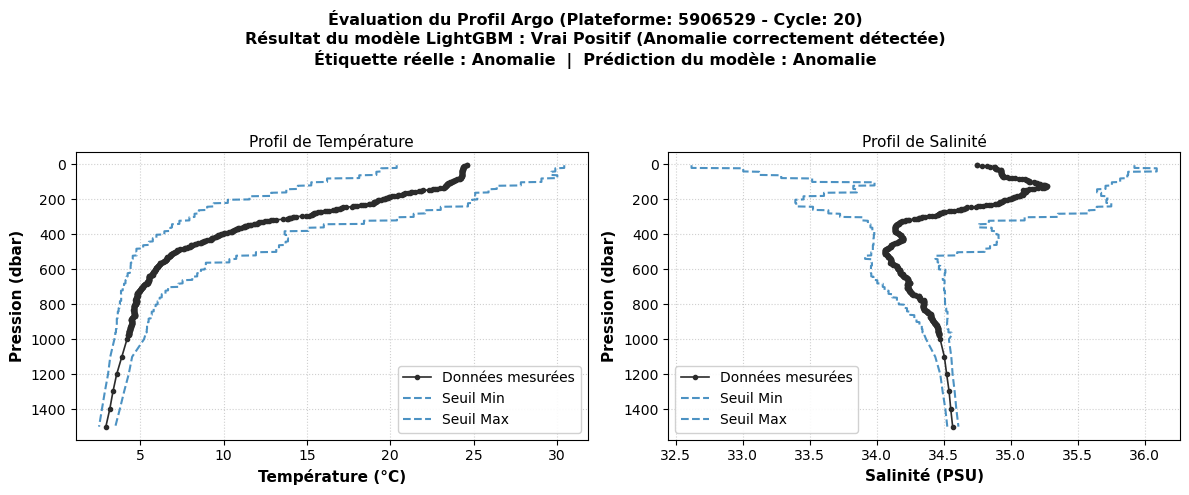


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 4902111 | Cycle = 237
Résultat LightGBM : Vrai Positif (Anomalie correctement détectée)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


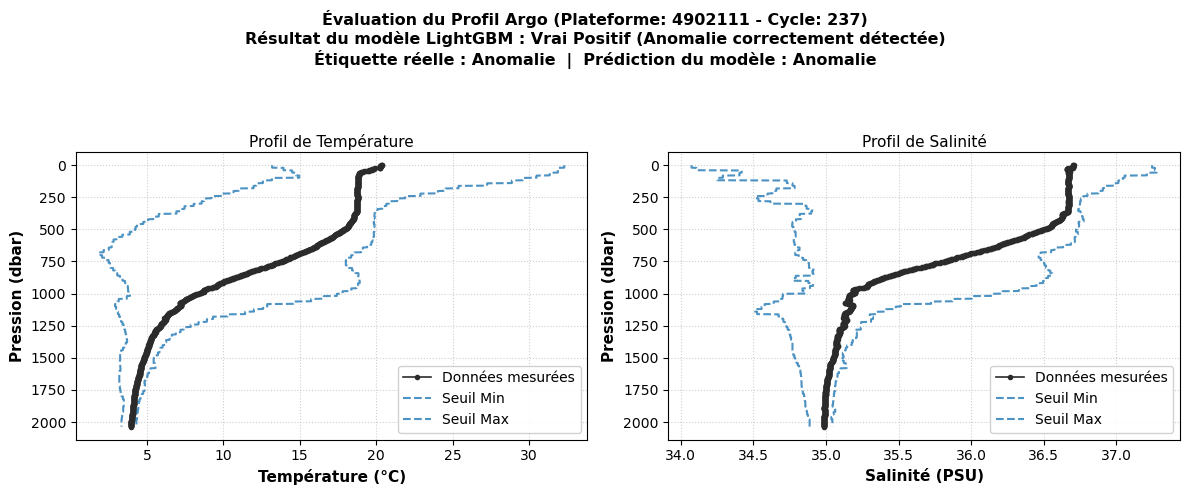


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 6900892 | Cycle = 116
Résultat LightGBM : Vrai Négatif (Profil normal correctement classé)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


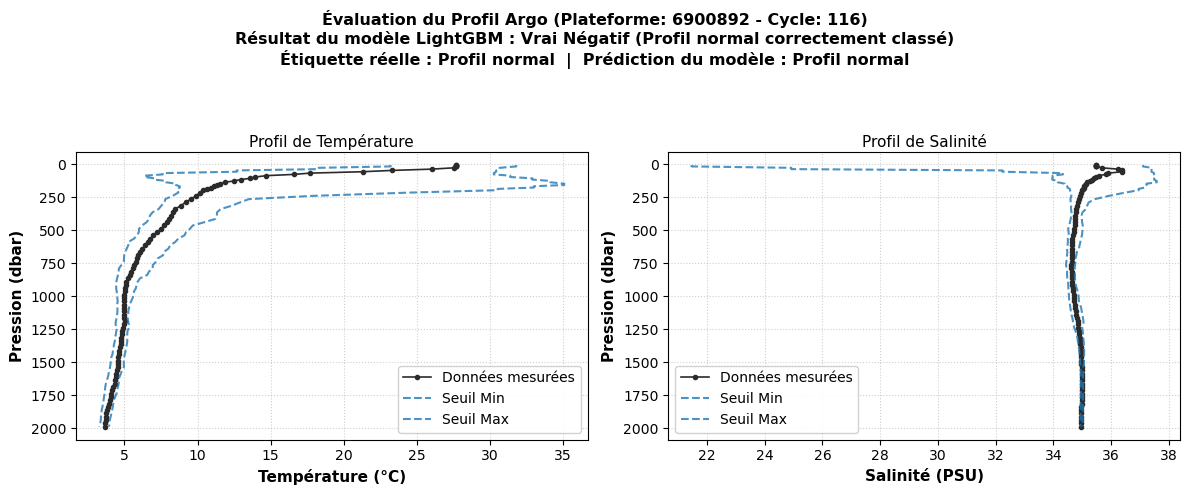


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5906354 | Cycle = 37
Résultat LightGBM : Vrai Négatif (Profil normal correctement classé)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


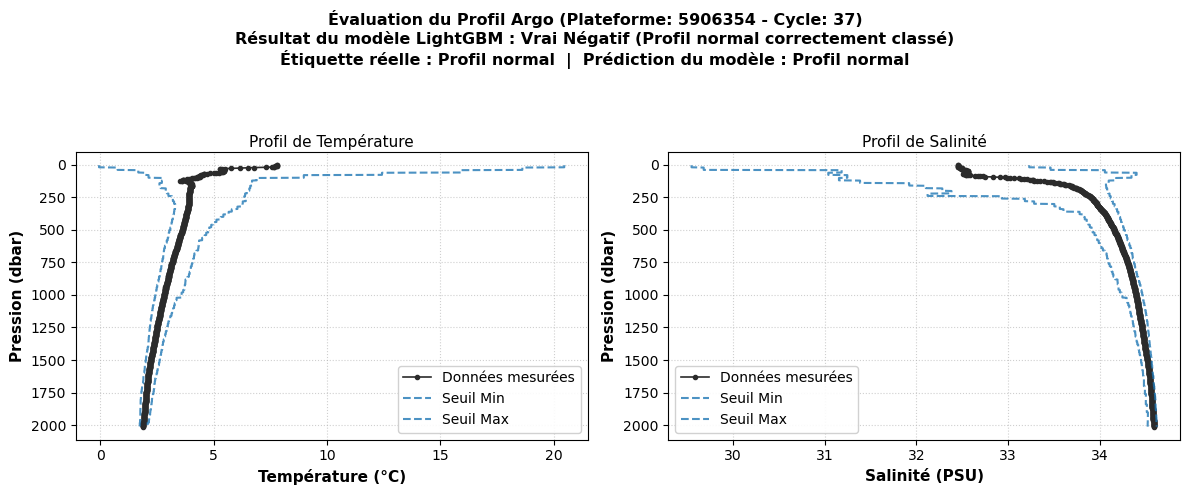


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 4903322 | Cycle = 86
Résultat LightGBM : Vrai Négatif (Profil normal correctement classé)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


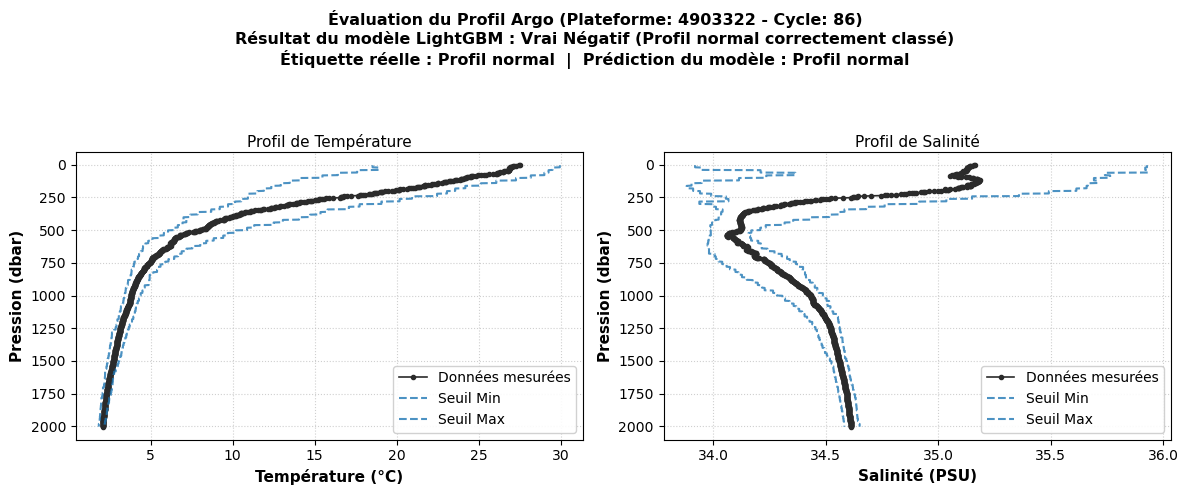


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5905025 | Cycle = 249
Résultat LightGBM : Vrai Négatif (Profil normal correctement classé)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


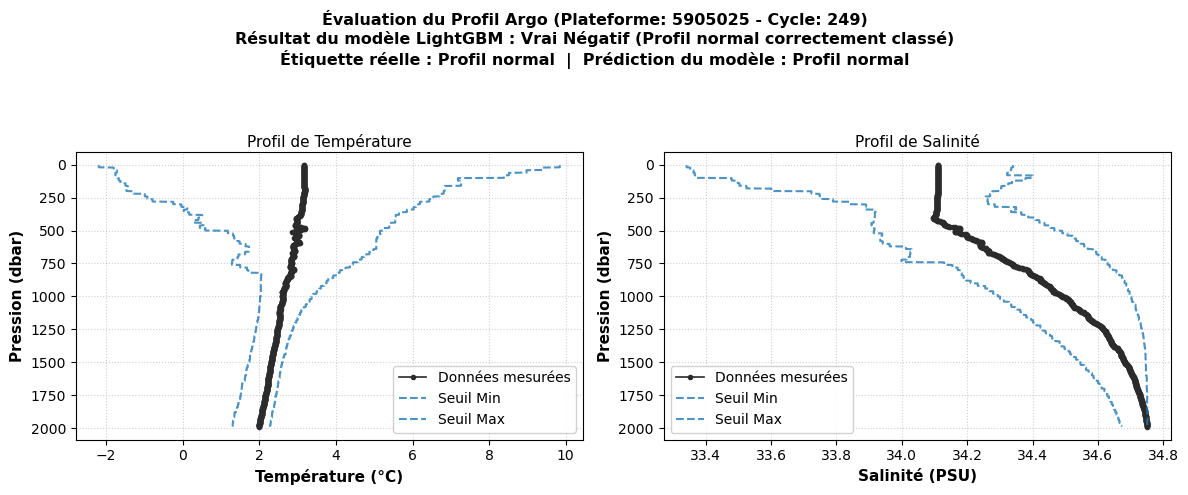


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 1901828 | Cycle = 299
Résultat LightGBM : Vrai Négatif (Profil normal correctement classé)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


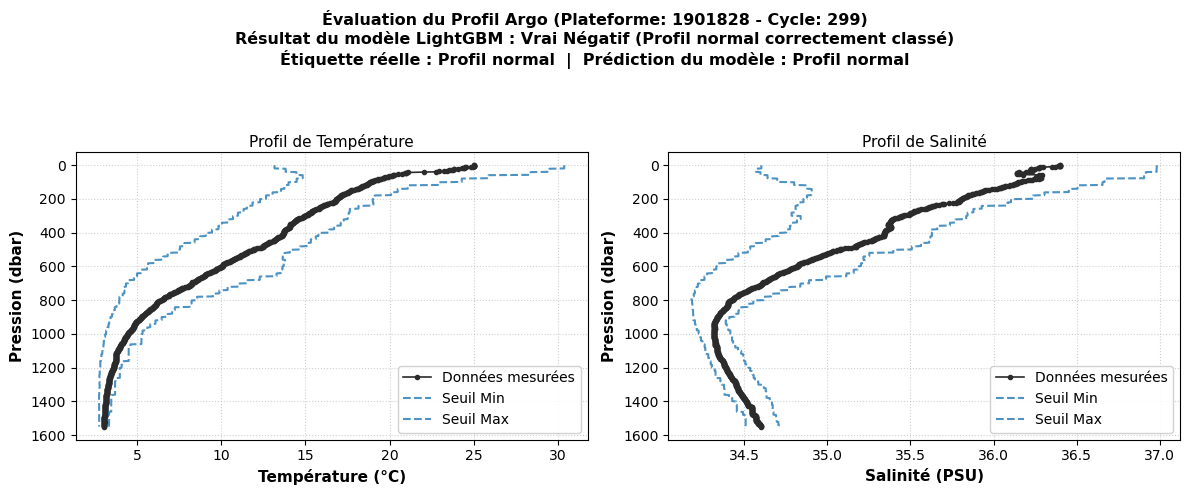


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5902411 | Cycle = 280
Résultat LightGBM : Faux Positif (Fausse alarme d'anomalie)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


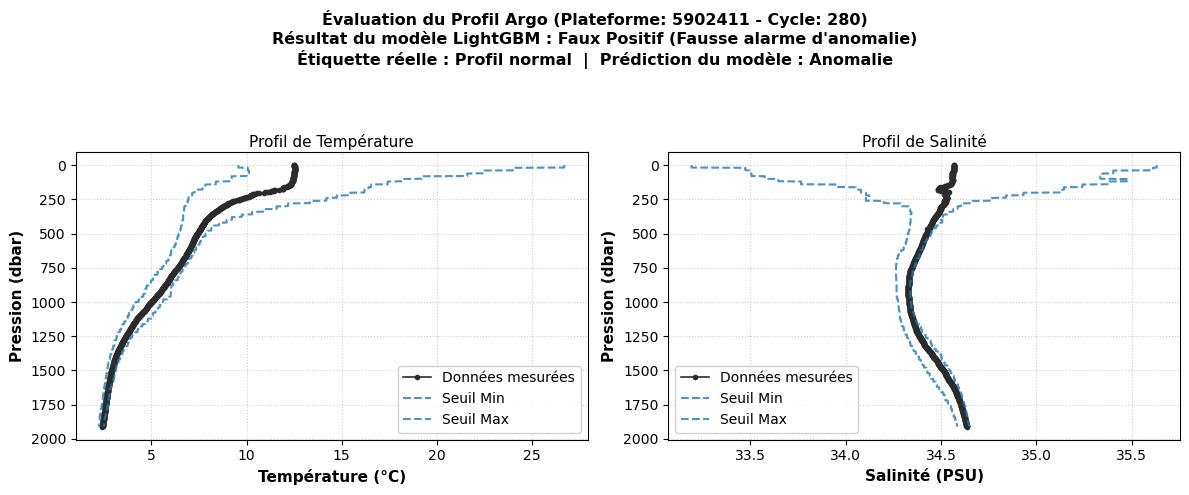


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5905404 | Cycle = 150
Résultat LightGBM : Faux Positif (Fausse alarme d'anomalie)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


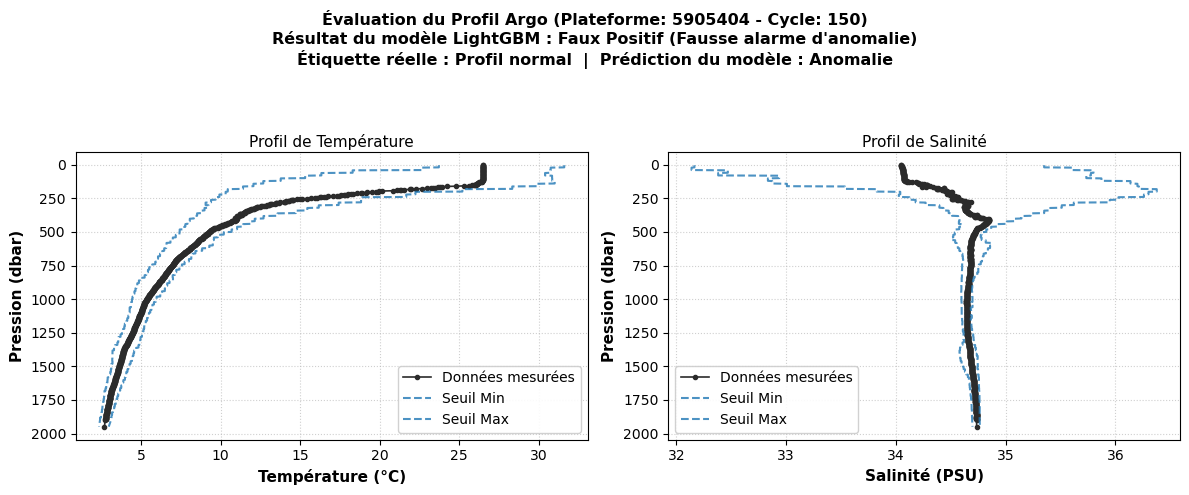


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5906111 | Cycle = 113
Résultat LightGBM : Faux Positif (Fausse alarme d'anomalie)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


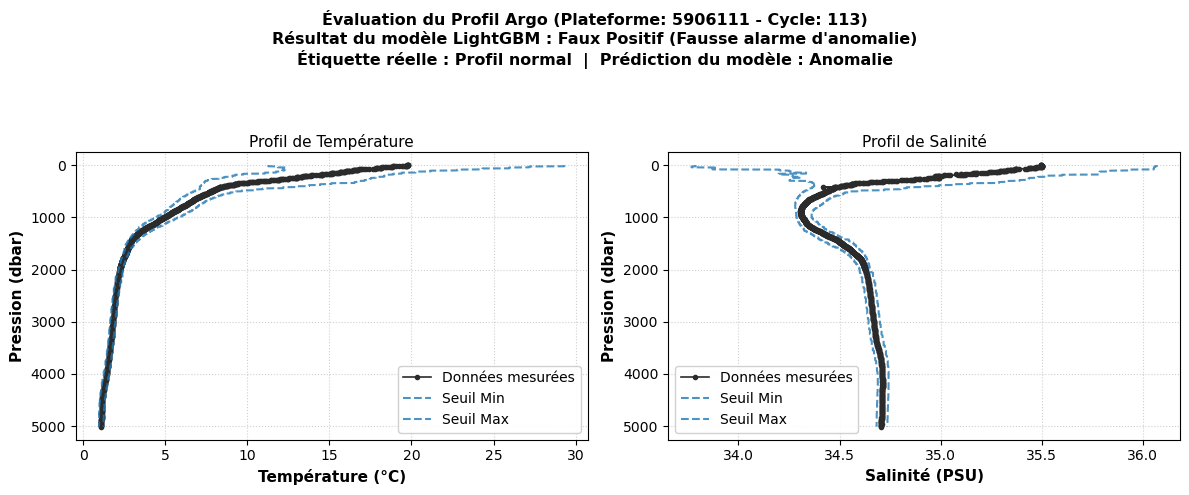


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5906439 | Cycle = 29
Résultat LightGBM : Faux Positif (Fausse alarme d'anomalie)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


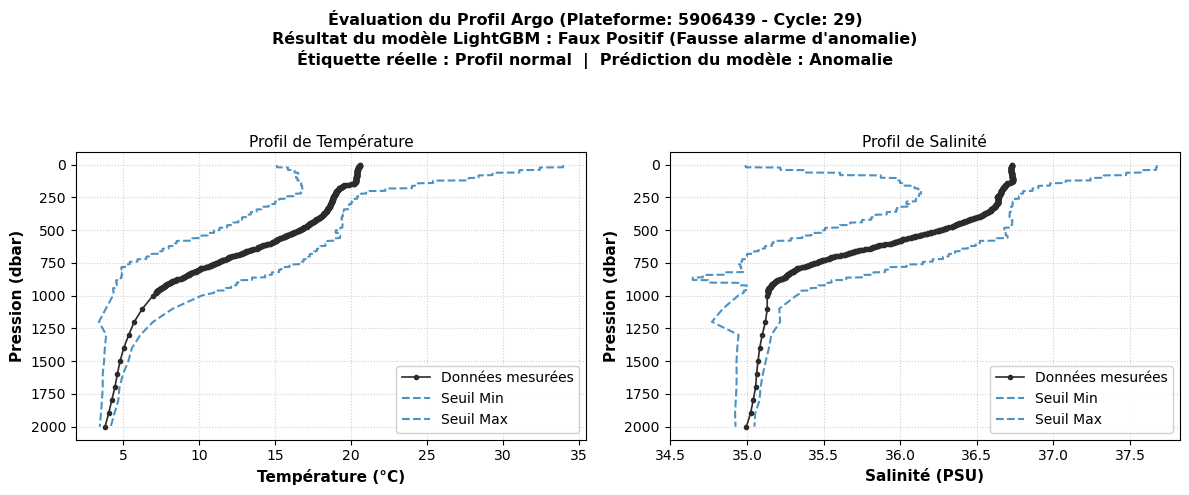


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 1901842 | Cycle = 197
Résultat LightGBM : Faux Positif (Fausse alarme d'anomalie)
  -> Étiquette réelle : Profil normal | Prédiction du modèle : Anomalie
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


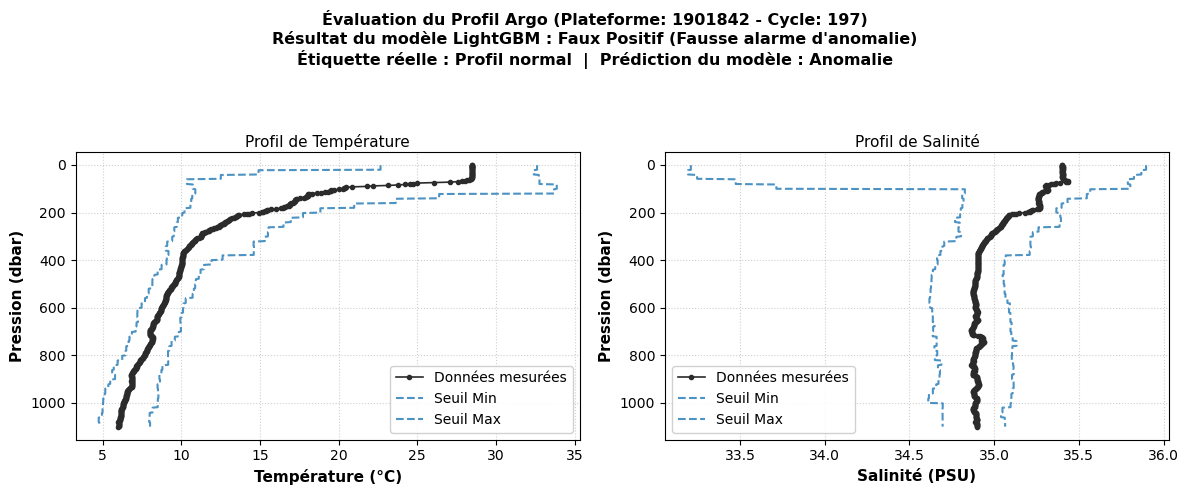


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 4902347 | Cycle = 229
Résultat LightGBM : Faux Négatif (Anomalie manquée par le modèle)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


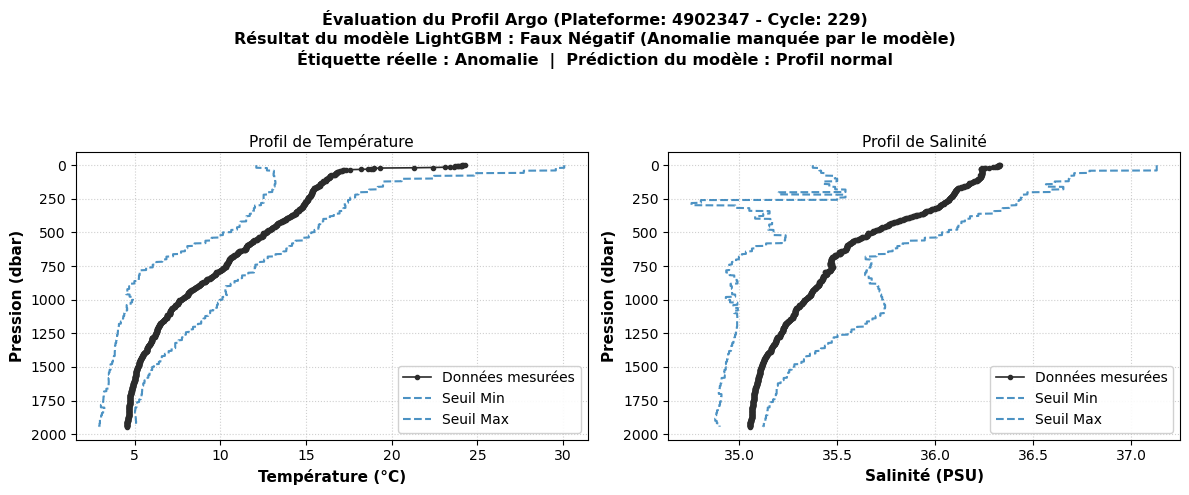


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5902395 | Cycle = 263
Résultat LightGBM : Faux Négatif (Anomalie manquée par le modèle)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 123 points | Température : 0 points
---------------------------------------------------------------------------


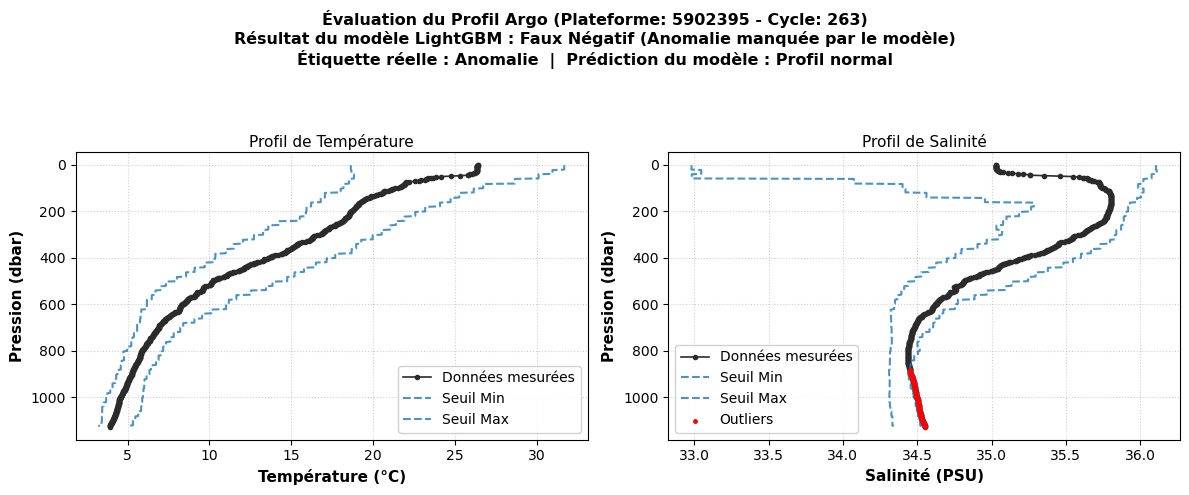


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 6903078 | Cycle = 33
Résultat LightGBM : Faux Négatif (Anomalie manquée par le modèle)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 0 points | Température : 0 points
---------------------------------------------------------------------------


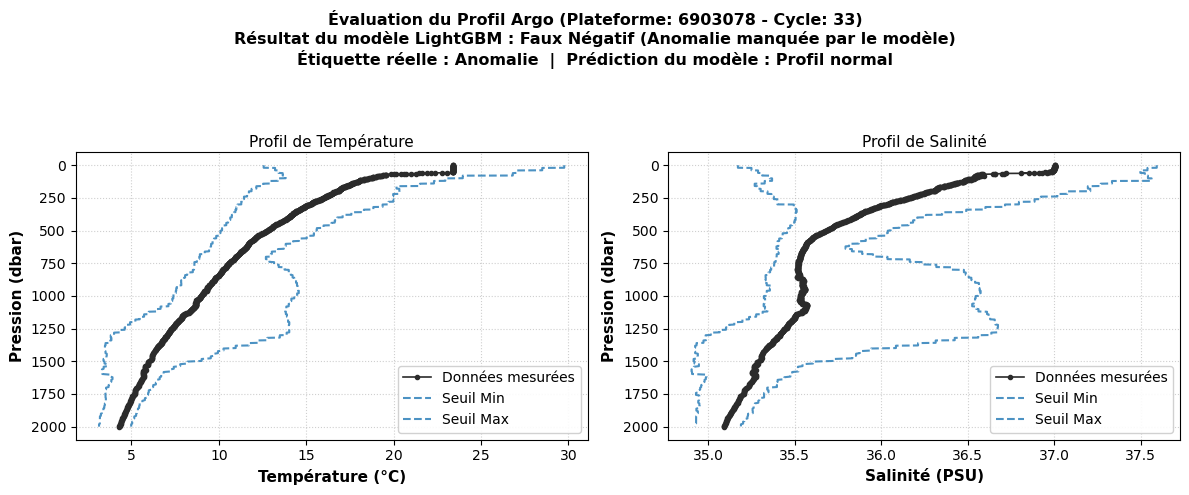


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 5902395 | Cycle = 259
Résultat LightGBM : Faux Négatif (Anomalie manquée par le modèle)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 78 points | Température : 0 points
---------------------------------------------------------------------------


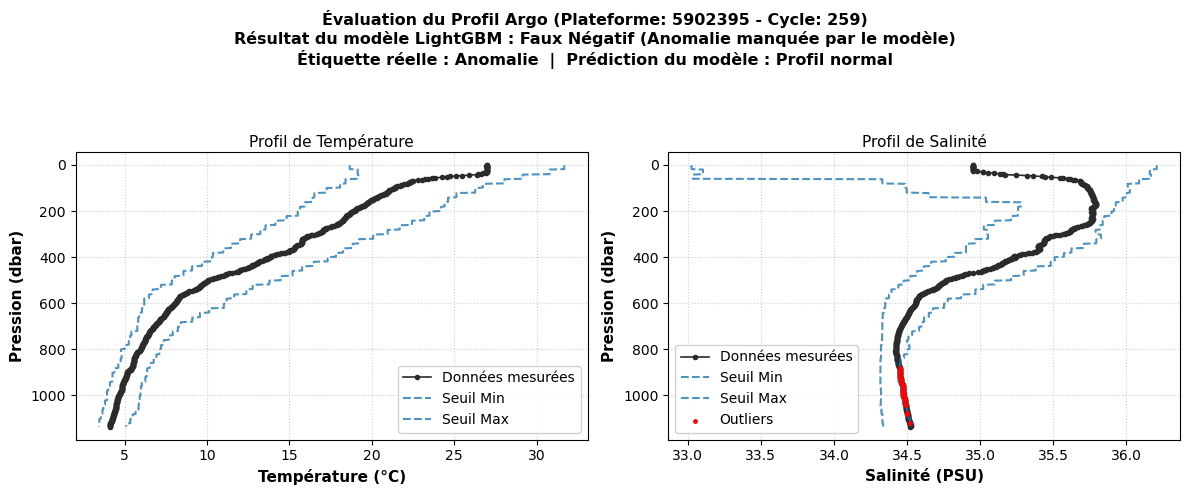


---------------------------------------------------------------------------
Analyse du profil : Plateforme = 3901822 | Cycle = 207
Résultat LightGBM : Faux Négatif (Anomalie manquée par le modèle)
  -> Étiquette réelle : Anomalie | Prédiction du modèle : Profil normal
  -> Outliers détectés - Salinité : 399 points | Température : 0 points
---------------------------------------------------------------------------


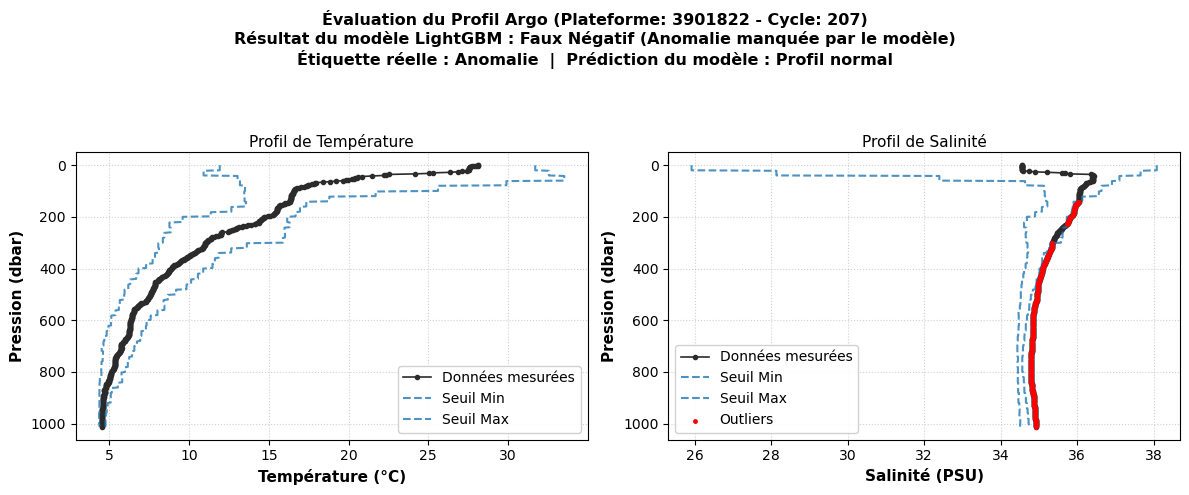

In [ ]:
#  Comparaison de chaque profil sélectionné avec le Min/Max et affichage
import os
import sys
import scipy.io as spio
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Configuration du répertoire principal
BASE_DIR = "/home/drgarcia/Argo_ml_code_clean/Min_Max_comparasion/MinMax"
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from Tools_MinMax_ISEA import lonlat2indexISEA, val2index

DIR_ISEA_AUXfiles = os.path.join(BASE_DIR, "AUX_files") + os.sep
ISEA_type = '4H6'

print("Chargement des fichiers de référence Min/Max...")
minmax_psal = xr.open_dataset(os.path.join(BASE_DIR, "REFERENCE_FILES", "PSAL_MIN_MAX.nc"))
minmax_temp = xr.open_dataset(os.path.join(BASE_DIR, "REFERENCE_FILES", "TEMP_MIN_MAX.nc"))
info_DGG = spio.loadmat(os.path.join(DIR_ISEA_AUXfiles, f"info_DGG{ISEA_type}.mat"))

def get_platform_numbers(data):
    """Extrait les numéros de plateforme du dataset de manière sécurisée."""
    raw = data.PLATFORM_NUMBER.data
    if isinstance(raw[0], bytes):
        return np.array([int(str(p, 'utf-8').strip()) for p in raw])
    return raw

def format_label_text(lbl):
    """Convertit toutes les variantes d'étiquettes (texte FR/EN ou numérique) en français."""
    lbl_str = str(lbl).strip().lower()
    if lbl_str in ['0', 'normal', 'profil normal']:
        return "Profil normal"
    elif lbl_str in ['1', 'anomaly', 'anomalie']:
        return "Anomalie"
    return str(lbl).strip()

def plot_profile_vs_minmax(nc_path, platform_number, cycle_number,
                           real_label, predicted_label, prediction_type):
    """
    Génère un graphique professionnel comparant le profil mesuré 
    aux limites climatologiques Min/Max.
    """
    data = xr.open_dataset(nc_path, engine='netcdf4')

    platform_numbers = get_platform_numbers(data)
    cycle_numbers = data.CYCLE_NUMBER.data

    mask = (platform_numbers == platform_number) & (cycle_numbers == cycle_number)
    idx_list = np.where(mask)[0]

    if len(idx_list) == 0:
        print(f" [Avertissement] Profil introuvable : Plateforme={platform_number}, Cycle={cycle_number}")
        data.close()
        return

    k = idx_list[0]
    lon = data.LONGITUDE.data[k]
    lat = data.LATITUDE.data[k]
    pres = data.PRES.data[k, :]
    psal = data.PSAL.data[k, :]
    temp = data.TEMP.data[k, :]

    lon_arr = np.array([lon])
    lat_arr = np.array([lat])
    hgrid_id = lonlat2indexISEA(lon_arr, lat_arr, info_DGG, ISEA_type)[0] - 1

    layer_id = val2index(pres, minmax_psal.depth.data)
    nonan = ~np.isnan(layer_id)

    psal_min = np.full_like(pres, np.nan)
    psal_max = np.full_like(pres, np.nan)
    temp_min = np.full_like(temp, np.nan)
    temp_max = np.full_like(temp, np.nan)

    if np.any(nonan):
        layer_id_valid = layer_id[nonan].astype(int)
        psal_min[nonan] = minmax_psal.psal_min.data[hgrid_id, layer_id_valid]
        psal_max[nonan] = minmax_psal.psal_max.data[hgrid_id, layer_id_valid]
        temp_min[nonan] = minmax_temp.temp_min.data[hgrid_id, layer_id_valid]
        temp_max[nonan] = minmax_temp.temp_max.data[hgrid_id, layer_id_valid]

    psal_outliers = (psal < psal_min) | (psal > psal_max)
    temp_outliers = (temp < temp_min) | (temp > temp_max)
    
    # Dictionnaire ML
    traduction_ml = {
        'TP': 'Vrai Positif (Anomalie correctement détectée)',
        'FP': 'Faux Positif (Fausse alarme d\'anomalie)',
        'FN': 'Faux Négatif (Anomalie manquée par le modèle)',
        'TN': 'Vrai Négatif (Profil normal correctement classé)'
    }
    prediction_desc = traduction_ml.get(prediction_type, prediction_type)

    real_label_str = format_label_text(real_label)
    predicted_label_str = format_label_text(predicted_label)

    print(f"\n{'-'*75}")
    print(f"Analyse du profil : Plateforme = {platform_number} | Cycle = {cycle_number}")
    print(f"Résultat LightGBM : {prediction_desc}")
    print(f"  -> Étiquette réelle : {real_label_str} | Prédiction du modèle : {predicted_label_str}")
    print(f"  -> Outliers détectés - Salinité : {np.sum(psal_outliers)} points | Température : {np.sum(temp_outliers)} points")
    print(f"{'-'*75}")

    # Configuration de la figure
    plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 11})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Titre général
    fig.suptitle(
        f'Évaluation du Profil Argo (Plateforme: {platform_number} - Cycle: {cycle_number})\n'
        f'Résultat du modèle LightGBM : {prediction_desc}\n'
        f'Étiquette réelle : {real_label_str}  |  Prédiction du modèle : {predicted_label_str}',
        fontsize=11.5, fontweight='bold', y=0.98
    )

    # --- Sous-graphique 1 : Température ---
    # Ligne affinée avec des points aux niveaux de mesure
    ax1.plot(temp, pres, color="#2b2b2b", linewidth=1.2, marker='o', markersize=3, label='Données mesurées')
    ax1.plot(temp_min, pres, color="#1f77b4", linestyle='--', linewidth=1.5, alpha=0.8, label='Seuil Min')
    ax1.plot(temp_max, pres, color="#1f77b4", linestyle='--', linewidth=1.5, alpha=0.8, label='Seuil Max')
    if np.any(temp_outliers):
        ax1.scatter(temp[temp_outliers], pres[temp_outliers], color="red",
                    s=25, marker='.', label='Outliers', zorder=5)
    
    ax1.legend(loc='lower right', framealpha=0.9)
    ax1.set_xlabel('Température (°C)', fontweight='bold')
    ax1.set_ylabel('Pression (dbar)', fontweight='bold')
    ax1.set_title('Profil de Température', pad=4)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.invert_yaxis()

    # --- Sous-graphique 2 : Salinité ---
    # Ligne affinée avec des points aux niveaux de mesure
    ax2.plot(psal, pres, color="#2b2b2b", linewidth=1.2, marker='o', markersize=3, label='Données mesurées')
    ax2.plot(psal_min, pres, color="#1f77b4", linestyle='--', linewidth=1.5, alpha=0.8, label='Seuil Min')
    ax2.plot(psal_max, pres, color="#1f77b4", linestyle='--', linewidth=1.5, alpha=0.8, label='Seuil Max')
    if np.any(psal_outliers):
        ax2.scatter(psal[psal_outliers], pres[psal_outliers], color="red",
                    s=25, marker='.', label='Outliers', zorder=5)
    
    ax2.legend(loc='best', framealpha=0.9)
    ax2.set_xlabel('Salinité (PSU)', fontweight='bold')
    ax2.set_ylabel('Pression (dbar)', fontweight='bold')
    ax2.set_title('Profil de Salinité', pad=4)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.invert_yaxis()

    plt.tight_layout(rect=[0, 0, 1, 0.91]) 
    plt.show()
    data.close()

# Boucle d'exécution
for _, row in selected.iterrows():
    platform = int(row["platform_number"])
    cycle = int(row["cycle_number"])
    nc_path = downloaded_files.get(platform)

    if nc_path is None:
        print(f"[Erreur] Impossible de traiter Plateforme={platform}, Cycle={cycle} (Fichier non téléchargé)")
        continue

    plot_profile_vs_minmax(
        nc_path, platform, cycle,
        real_label=row["real_label"],
        predicted_label=row["predicted_label"],
        prediction_type=row["prediction_type"],
    )